# Vector Datasets and `geopandas`

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file('nat_earth_countries.gpkg')
uk_gdf = gdf[gdf['NAME'] == 'United Kingdom']

In [4]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

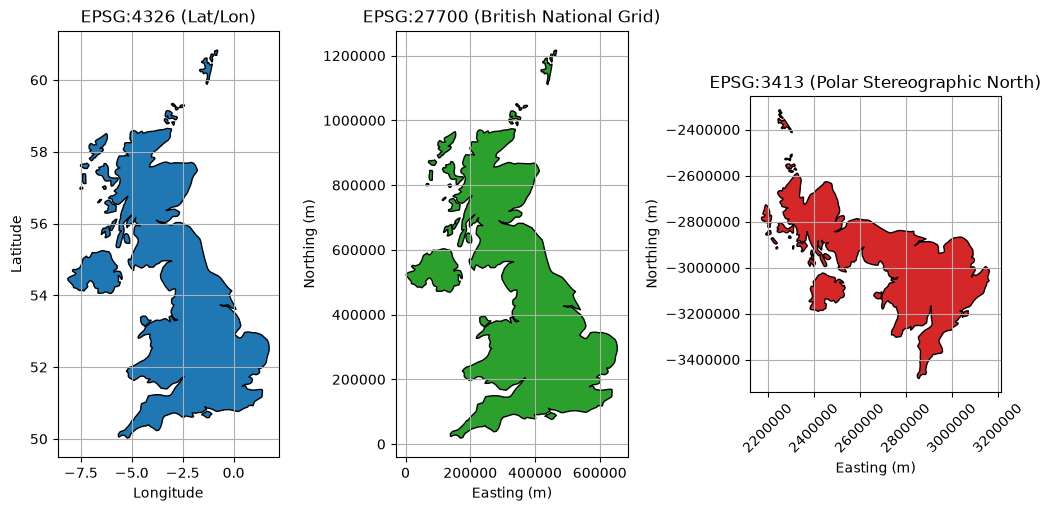

In [16]:
# Plot the UK shapefile in (i) EPSG:3413 (lat/lon), (ii) EPSG:2770 (British National Grid), and (iii) EPSG:4258 (European Terrestrial Reference System) projections. Include appropriate x/y labels

fig, axes = plt.subplots(1, 3, figsize=(10, 5), layout='constrained')

ax = axes[0]
uk_gdf.to_crs(epsg=4326).plot(ax=ax, color='tab:blue', edgecolor='black')
ax.set_title('EPSG:4326 (Lat/Lon)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid()

ax = axes[1]
uk_gdf.to_crs(epsg=27700).plot(ax=ax, color='tab:green', edgecolor='black')
ax.set_title('EPSG:27700 (British National Grid)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.ticklabel_format(style='plain', useOffset=False)
ax.grid()

ax = axes[2]
uk_gdf.to_crs(epsg=3413).plot(ax=ax, color='tab:red', edgecolor='black')
ax.set_title('EPSG:3413 (Polar Stereographic North)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.ticklabel_format(style='plain', useOffset=False)
ax.grid()
# rotate y axis labels by 45 degrees
for label in ax.get_xticklabels():
    label.set_rotation(45)


In [17]:
fpath = "/Users/ju24811/Downloads/ne_50m_populated_places/ne_50m_populated_places.shp"
cities_gdf = gpd.read_file(fpath)

In [31]:
for i in cities_gdf.columns:
    print(i)

SCALERANK
NATSCALE
LABELRANK
FEATURECLA
NAME
NAMEPAR
NAMEALT
NAMEASCII
ADM0CAP
CAPIN
WORLDCITY
MEGACITY
SOV0NAME
SOV_A3
ADM0NAME
ADM0_A3
ADM1NAME
ISO_A2
NOTE
LATITUDE
LONGITUDE
POP_MAX
POP_MIN
POP_OTHER
RANK_MAX
RANK_MIN
MEGANAME
LS_NAME
MAX_POP10
MAX_POP20
MAX_POP50
MAX_POP300
MAX_POP310
MAX_NATSCA
MIN_AREAKM
MAX_AREAKM
MIN_AREAMI
MAX_AREAMI
MIN_PERKM
MAX_PERKM
MIN_PERMI
MAX_PERMI
MIN_BBXMIN
MAX_BBXMIN
MIN_BBXMAX
MAX_BBXMAX
MIN_BBYMIN
MAX_BBYMIN
MIN_BBYMAX
MAX_BBYMAX
MEAN_BBXC
MEAN_BBYC
TIMEZONE
UN_FID
POP1950
POP1955
POP1960
POP1965
POP1970
POP1975
POP1980
POP1985
POP1990
POP1995
POP2000
POP2005
POP2010
POP2015
POP2020
POP2025
POP2050
MIN_ZOOM
WIKIDATAID
WOF_ID
CAPALT
NAME_EN
NAME_DE
NAME_ES
NAME_FR
NAME_PT
NAME_RU
NAME_ZH
LABEL
NAME_AR
NAME_BN
NAME_EL
NAME_HI
NAME_HU
NAME_ID
NAME_IT
NAME_JA
NAME_KO
NAME_NL
NAME_PL
NAME_SV
NAME_TR
NAME_VI
NE_ID
NAME_FA
NAME_HE
NAME_UK
NAME_UR
NAME_ZHT
GEONAMESID
FCLASS_ISO
FCLASS_US
FCLASS_FR
FCLASS_RU
FCLASS_ES
FCLASS_CN
FCLASS_TW
FCLASS_IN
FCLASS_N

In [37]:
cities_gdf.clip(uk_gdf).MAX_AREAKM


237      192.0
786      483.0
94       290.0
1227    3198.0
236      842.0
126     1052.0
93       175.0
Name: MAX_AREAKM, dtype: float64